# Multi-Agent Interaction Analysis

In [1]:
import json
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from matplotlib_venn import venn2, venn3

%matplotlib inline

In [2]:
STOP_WORDS = {
    "the", "a", "an", "and", "or", "but", "in", "on", "at", "to", "for",
    "of", "with", "is", "it", "that", "this", "we", "i", "you", "they",
    "be", "are", "was", "were", "have", "has", "had", "not", "about",
    "their", "our", "can", "just", "so", "if", "when", "how", "what",
    "more", "really", "think", "feel", "truly", "also", "still", "even",
    "would", "could", "should", "might", "need", "use", "used", "using",
    "do", "did", "does", "been", "being", "all", "some", "any", "no",
    "up", "out", "than", "then", "my", "me", "him", "her", "its", "am",
    "very", "well", "here", "there", "from", "into", "by", "as", "like",
    "will", "get", "much", "too", "point", "way", "good", "right", "see",
    "things", "something", "sure", "bit", "make", "going", "want", "know",
    "actually", "perhaps", "maybe", "quite", "however", "though", "while",
    "across", "them", "us", "those", "these", "each", "both", "only",
    "already", "yes", "no", "own", "agree", "think", "believe", "feel"
}

KEY_THEMES = [
    "critical thinking", "over-rely", "dependency", "misuse", "fairness",
    "creativity", "personalize", "personalized", "guidelines", "boundaries",
    "responsibility", "responsible", "access", "equity", "engagement",
    "brainstorm", "research", "feedback", "learning", "harm",
    "benefits", "risks", "moderation", "integrity", "shortcuts",
    "skills", "independent", "reliance", "support", "adoption"
]


def extract_themes(text: str) -> set:
    text = text.lower()
    found = set()
    for theme in KEY_THEMES:
        if theme in text:
            found.add(theme)
    return found


def load_trial(path: str) -> dict:
    with open(path, encoding="utf-8") as f:
        return json.load(f)


def get_trial_themes(trial: dict) -> set:
    themes = set()
    for agent in trial["agents"]:
        for trace in agent["traces"]:
            for field in ["observation_summary", "thought", "influence_analysis",
                          "updated_belief", "updated_goal", "message"]:
                if field in trace:
                    themes |= extract_themes(trace[field])
        themes |= extract_themes(agent.get("final_belief", ""))
        for mem in agent.get("memories", []):
            themes |= extract_themes(mem)
    return themes


def get_trial_stances(trial: dict) -> dict:
    return {
        agent["name"]: agent["stance_history"]
        for agent in trial["agents"]
    }

## Load Trial Data

In [3]:
paths = sorted(glob.glob("trial_*.json"))
if not paths:
    print("No trial_*.json files found. Run agent.py first.")
else:
    trials = [load_trial(p) for p in paths]
    labels = [f"Trial {t['trial_id']}" for t in trials]
    theme_sets = [get_trial_themes(t) for t in trials]
    all_stances = [get_trial_stances(t) for t in trials]
    print(f"Loaded {len(trials)} trial(s): {labels}")

Loaded 5 trial(s): ['Trial 1', 'Trial 2', 'Trial 3', 'Trial 4', 'Trial 5']


## Theme Analysis

In [4]:
all_themes = set().union(*theme_sets)
shared_all = theme_sets[0].copy()
for s in theme_sets[1:]:
    shared_all &= s

unique = [s - set().union(*[theme_sets[j] for j in range(len(theme_sets)) if j != i])
          for i, s in enumerate(theme_sets)]

print(f"Shared across ALL {len(theme_sets)} trials:")
for t in sorted(shared_all):
    print(f"  • {t}")

for i, label in enumerate(labels):
    print(f"\nUnique to {label}:")
    for t in sorted(unique[i]):
        print(f"  • {t}")

print(f"\nAll themes observed: {sorted(all_themes)}")

Shared across ALL 5 trials:
  • benefits
  • critical thinking
  • engagement
  • guidelines
  • independent
  • learning
  • reliance
  • responsible
  • skills
  • support

Unique to Trial 1:
  • adoption
  • misuse

Unique to Trial 2:
  • dependency
  • shortcuts

Unique to Trial 3:
  • harm

Unique to Trial 4:

Unique to Trial 5:

All themes observed: ['adoption', 'benefits', 'boundaries', 'brainstorm', 'creativity', 'critical thinking', 'dependency', 'engagement', 'guidelines', 'harm', 'independent', 'learning', 'misuse', 'moderation', 'reliance', 'research', 'responsible', 'risks', 'shortcuts', 'skills', 'support']


## Venn Diagram: Theme Overlap Across Trials

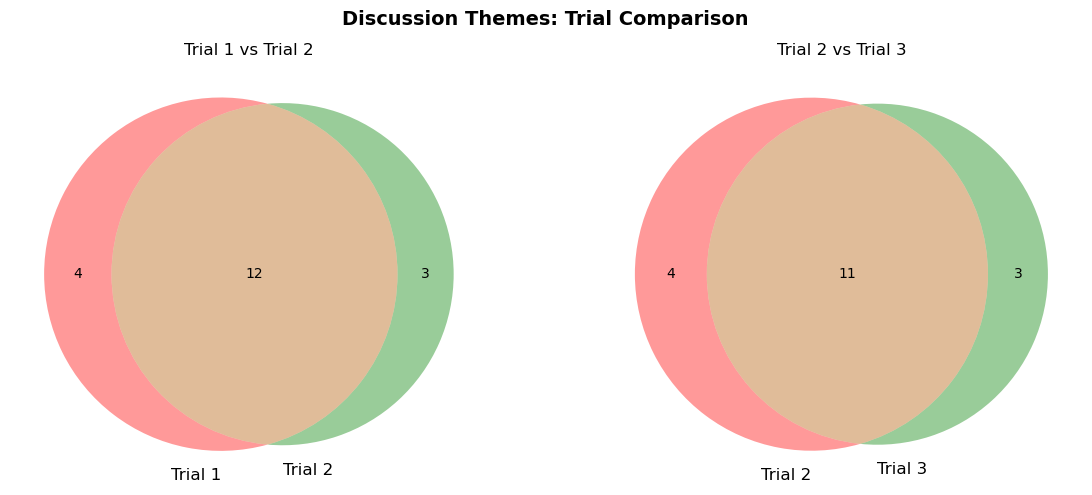

In [5]:
sets = theme_sets[:3]
lbls = labels[:3]

fig, axes = plt.subplots(1, len(sets) - 1, figsize=(6 * (len(sets) - 1), 5))
if len(sets) - 1 == 1:
    axes = [axes]

for i in range(len(sets) - 1):
    ax = axes[i]
    a, b = sets[i], sets[i + 1]
    la, lb = lbls[i], lbls[i + 1]
    venn2([a, b], set_labels=(la, lb), ax=ax)
    ax.set_title(f"{la} vs {lb}")

fig.suptitle("Discussion Themes: Trial Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Stance Evolution per Agent

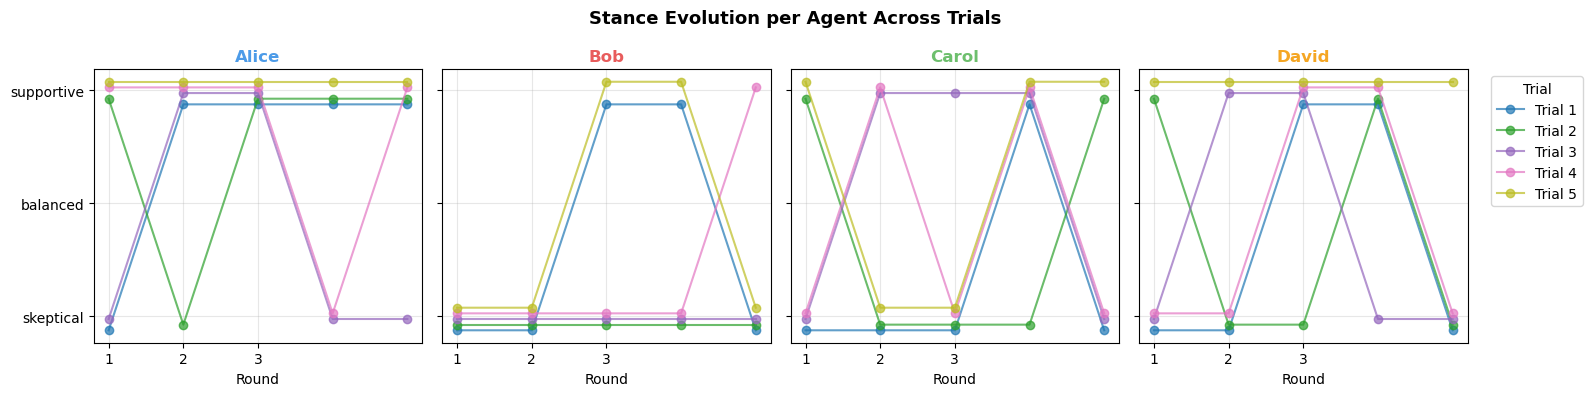

In [6]:
agents = list(all_stances[0].keys())
stance_to_num = {"supportive": 1, "balanced": 0, "skeptical": -1}
colors = {"Alice": "#4C9BE8", "Bob": "#E85C5C", "Carol": "#6DBF6D", "David": "#F5A623"}

fig, axes = plt.subplots(1, len(agents), figsize=(4 * len(agents), 4), sharey=True)
fig.suptitle("Stance Evolution per Agent Across Trials", fontsize=13, fontweight="bold")

for ax, agent in zip(axes, agents):
    for i, (stances, label) in enumerate(zip(all_stances, labels)):
        history = stances.get(agent, [])
        nums = [stance_to_num.get(s, 0) for s in history]
        rounds = list(range(1, len(nums) + 1))
        
        jitter = (i - len(labels) / 2) * 0.05  # <-- inside loop, uses `labels` not `trial_labels`
        ax.plot(rounds, [n + jitter for n in nums], marker="o", label=label, alpha=0.7,
                color=plt.cm.tab10(i / len(labels)))  # <-- one plot call, not two

    ax.set_title(agent, color=colors.get(agent, "black"), fontweight="bold")
    ax.set_yticks([-1, 0, 1])
    ax.set_yticklabels(["skeptical", "balanced", "supportive"])
    ax.set_xlabel("Round")
    ax.set_xticks(range(1, 4))
    ax.grid(True, alpha=0.3)

axes[-1].legend(title="Trial", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## New Visuals: Influence Network, Belief Drift & Convergence

In [7]:
# Shared constants and helpers used by all three new visuals
AGENT_NAMES = ["Alice", "Bob", "Carol", "David"]
AGENT_COLORS = {"Alice": "#4C9BE8", "Bob": "#E85C5C", "Carol": "#6DBF6D", "David": "#F5A623"}
STANCE_TO_NUM = {"supportive": 1, "balanced": 0, "skeptical": -1}

def parse_influencer(text: str):
    # Finds the first agent name mentioned in an influence_analysis string
    for name in AGENT_NAMES:
        if name.lower() in text.lower():
            return name
    return None

### Influence Network
Who influenced whom most across all trials? Arrow thickness = how often that influence was recorded.

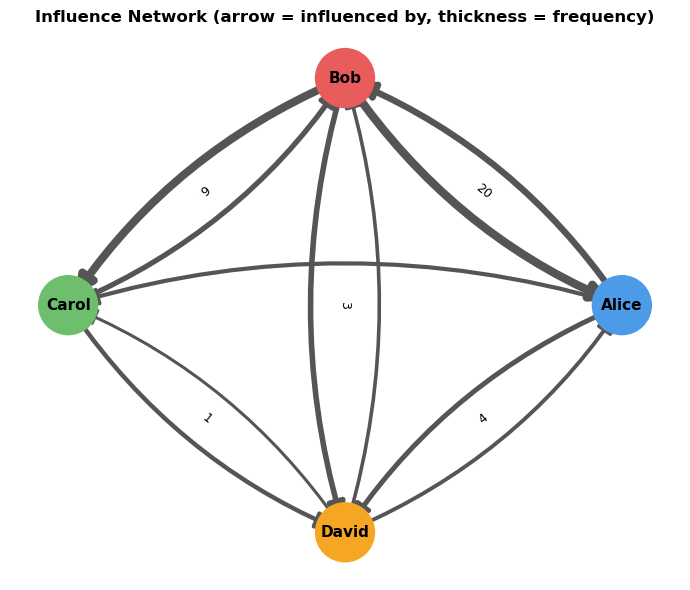

In [8]:
# Count how many times each agent is named as the influencer for each other agent
counts = {}
for trial in trials:
    for agent in trial["agents"]:
        influenced = agent["name"]
        for trace in agent["traces"]:
            influencer = parse_influencer(trace.get("influence_analysis", ""))
            if influencer and influencer != influenced:
                key = (influencer, influenced)
                counts[key] = counts.get(key, 0) + 1

# Build and draw the directed graph
G = nx.DiGraph()
G.add_nodes_from(AGENT_NAMES)
for (src, dst), weight in counts.items():
    G.add_edge(src, dst, weight=weight)

fig, ax = plt.subplots(figsize=(7, 6))
pos = nx.circular_layout(G)
node_colors = [AGENT_COLORS.get(n, "#aaaaaa") for n in G.nodes()]
edge_weights = [G[u][v]["weight"] for u, v in G.edges()]
max_w = max(edge_weights) if edge_weights else 1

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1800, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=11, font_weight="bold", ax=ax)
nx.draw_networkx_edges(
    G, pos,
    width=[2 + 4 * (w / max_w) for w in edge_weights],
    edge_color="#555555",
    arrows=True,
    arrowsize=25,
    connectionstyle="arc3,rad=0.15",
    ax=ax,
)
nx.draw_networkx_edge_labels(G, pos, edge_labels={(u, v): G[u][v]["weight"] for u, v in G.edges()},
                              font_size=9, ax=ax)

ax.set_title("Influence Network (arrow = influenced by, thickness = frequency)", fontsize=12, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

### Belief Drift Per Agent
How far did each agent's belief move from where they started? 0.0 = no change, 1.0 = completely different.
Shaded area = variation across trials.

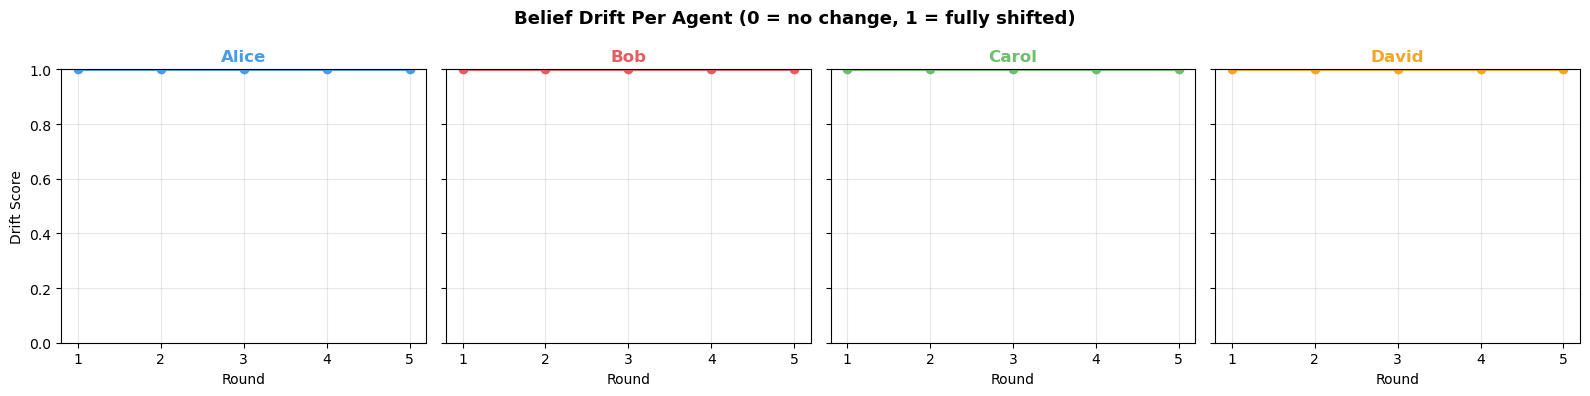

In [9]:
fig, axes = plt.subplots(1, len(AGENT_NAMES), figsize=(4 * len(AGENT_NAMES), 4), sharey=True)
fig.suptitle("Belief Drift Per Agent (0 = no change, 1 = fully shifted)", fontsize=13, fontweight="bold")

for ax, agent_name in zip(axes, AGENT_NAMES):
    round_drifts = {}
    for trial in trials:
        for agent in trial["agents"]:
            if agent["name"] != agent_name:
                continue
            for trace in agent["traces"]:
                r = trace["round"]
                d = trace.get("belief_drift")
                if d is not None:
                    round_drifts.setdefault(r, []).append(d)

    if not round_drifts:
        ax.text(0.5, 0.5, "no drift data\n(run new trials)", ha="center", va="center", transform=ax.transAxes, fontsize=9)
        ax.set_title(agent_name, color=AGENT_COLORS[agent_name], fontweight="bold")
        continue

    rounds_sorted = sorted(round_drifts.keys())
    means = [np.mean(round_drifts[r]) for r in rounds_sorted]
    stds  = [np.std(round_drifts[r])  for r in rounds_sorted]
    color = AGENT_COLORS[agent_name]

    ax.plot(rounds_sorted, means, marker="o", color=color, linewidth=2)
    ax.fill_between(rounds_sorted,
                    [m - s for m, s in zip(means, stds)],
                    [m + s for m, s in zip(means, stds)],
                    alpha=0.2, color=color)
    ax.set_title(agent_name, color=color, fontweight="bold")
    ax.set_xlabel("Round")
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Drift Score")
plt.tight_layout()
plt.show()

### Convergence Curve
Did the group actually reach agreement? Low std dev = agents aligned. High std dev = still divided.

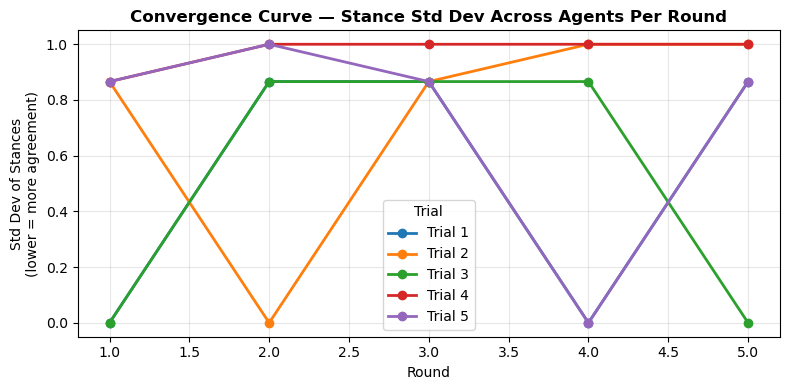

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))

for stances, label in zip(all_stances, labels):
    agents_list = list(stances.keys())
    num_rounds = max(len(stances[a]) for a in agents_list)
    std_per_round = []

    for r in range(num_rounds):
        values = [STANCE_TO_NUM.get(stances[a][r], 0) for a in agents_list if r < len(stances[a])]
        if values:
            std_per_round.append(np.std(values))

    ax.plot(range(1, len(std_per_round) + 1), std_per_round, marker="o", label=label, linewidth=2)

ax.set_title("Convergence Curve — Stance Std Dev Across Agents Per Round", fontsize=12, fontweight="bold")
ax.set_xlabel("Round")
ax.set_ylabel("Std Dev of Stances\n(lower = more agreement)")
ax.legend(title="Trial")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()